In [2]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

experiments_objects = [JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, # JAL6_flip7_1apr, # a funky session
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_flip4_10may, JAL8_14may]

In [3]:
from behave_analysis.process.session import get_experiment 
from JR_test_scripts.tracking2features import tracking_to_features, extract_pa_across_sesh
from behave_analysis.analyze.behaviour.plot_homings import hist_initial_heading_angle

import os
import dill as pickle
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
# fixed vars
ceph_path = r"Z:\Jasmine_Laurence\Experimental_Data"
winstor_path = r"Y:\Laurence"
save_path = r"Z:\Jasmine_Laurence\LDA_overview\behavior"
conditions = ['shelter_only','barrier_pre_flip','barrier_post_flip']
all_angles = ['hdir','hsa','h_preflipbar_a','h_postflipbar_a','h_rightbar_a','h_leftbar_a']
all_features = ['shelter','preflip_barrier','postflip_barrier','left_barrier', 'right_barrier', 'arena_bottom', 'arena_top']
settings = 'all_angles_fr'
# 'all_angles_fr','all_angles_fr_excl_prox_15cm','all_angles_subsampled_fr','all_angles_subsampled_fr_excl_prox_15cm'

In [12]:
# pulling out prediction accuracy for all sessions for a certain set of settings

sessy, all_names, avg_pa, pa = extract_pa_across_sesh(all_angles,experiments_objects, conditions, all_features, settings)

Compare to spatial efficiency in escape


In [28]:
'''compare to ESCAPE spatial efficiency'''
se = {}
for c in conditions:
    se[c] = np.empty((len(experiments_objects)))

for s,sesh in enumerate(experiments_objects):
    # find session
    session = get_experiment(sesh)
    
    # load tracking
    esc_path = os.path.join(session.base_path,session.processed_path,'escapes',r"escapes_obj.pkl")
    with open(esc_path, "rb") as dill_file:
        esc = pickle.load(dill_file)
    for c in conditions:
        se[c][s] = np.nanmean(np.array([x for x, y in zip(esc.spatial_efficiency,esc.escape_condition) if y == c]))

C:\Users\Jasmine\AppData\Local\Temp\ipykernel_8700\2441252761.py:15: RuntimeWarning: Mean of empty slice
  se[c][s] = np.nanmean(np.array([x for x, y in zip(esc.spatial_efficiency,esc.escape_condition) if y == c]))


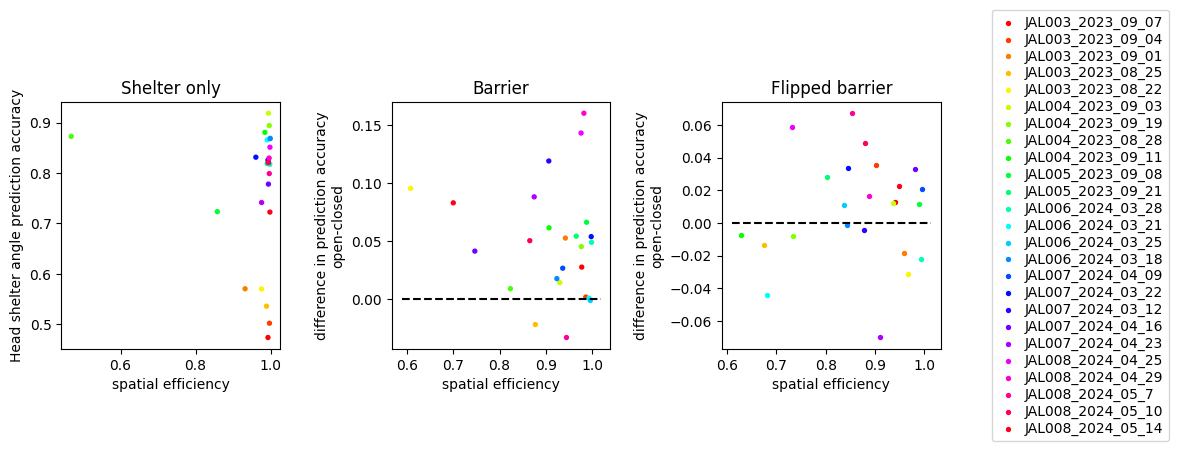

In [38]:
%matplotlib inline
fig, axs = plt.subplots(1,3, figsize = (4*len(conditions),4))
colorz = plt.cm.hsv(np.linspace(0, 1, len(se['shelter_only'])))
# shelter only
axs[0].scatter(se['shelter_only'],pa['hsa'][:,0],s=8,c=colorz)
axs[0].set_xlabel('spatial efficiency')
axs[0].set_ylabel('Head shelter angle prediction accuracy')
axs[0].set_title('Shelter only')

# barrier_pre_flip
axs[1].scatter(se['barrier_pre_flip'],pa['h_preflipbar_a'][:,1]-pa['h_postflipbar_a'][:,1],s=8,c=colorz)
axs[1].plot(axs[1].get_xlim(),[0,0],'--k')
axs[1].set_xlabel('spatial efficiency')
axs[1].set_ylabel('difference in prediction accuracy\nopen-closed')
axs[1].set_title('Barrier')

# barrier_post_flip
line_object = []
for s,p,cz in zip(se['barrier_post_flip'],pa['h_postflipbar_a'][:,2]-pa['h_preflipbar_a'][:,2],colorz):
    line = axs[2].scatter(s,p,s=8,color=cz)
    line_object.append(line)
axs[2].plot(axs[2].get_xlim(),[0,0],'--k')
axs[2].set_xlabel('spatial efficiency')
axs[2].set_ylabel('difference in prediction accuracy\nopen-closed')
axs[2].set_title('Flipped barrier')

axs[2].legend(line_object, all_names,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)


plt.tight_layout()
plt.savefig(save_path+'/'+str('escape_spatial_efficiency_pa_diff_allsesh_'+settings+'.png'))

Compare prediction accuracy to homings
- spatial efficiency
- number of homing (correct to target)
- fraction of homings (correct to target)

In [13]:
'''compare to HOMING spatial efficiency'''
se = {}
head = {}
for c in conditions:
    se[c] = np.empty((len(experiments_objects)))
    head[c] = np.empty((len(experiments_objects),3))

for s,sesh in enumerate(experiments_objects):
    # find session
    session = get_experiment(sesh)
    
    # load tracking
    track_path = os.path.join(session.base_path,session.processed_path,r"fully_processed_tracking_data.pickle")
    with open(track_path, "rb") as dill_file:
        tracking_data = pickle.load(dill_file)
    
    # load homings
    h_path = os.path.join(session.base_path,session.processed_path,'homings',r"homings_obj.pkl")
    with open(h_path, "rb") as dill_file:
        h = pickle.load(dill_file)

    heading = hist_initial_heading_angle(session, h.onset_frames, h.offset_frames, h.homing_angles_dic["avg_hdir"], h.homing_condition, tracking_data, "homing", show_plots=False, plotting = False)
    
    # spatial efficiency
    for c in conditions:
        se[c][s] = np.mean([x for x, y in zip(h.spatial_efficiency,h.homing_condition) if y == c])
        head[c][s,:] = heading[c]

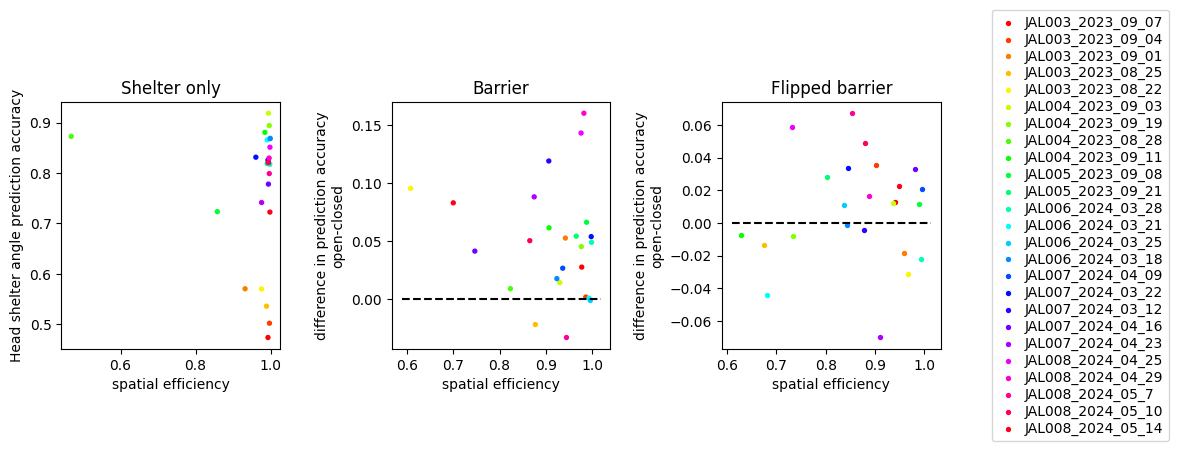

In [36]:
fig, axs = plt.subplots(1,3, figsize = (4*len(conditions),4))
colorz = plt.cm.hsv(np.linspace(0, 1, len(se['shelter_only'])))
# shelter only
axs[0].scatter(se['shelter_only'],pa['hsa'][:,0],s=8,c=colorz)
axs[0].set_xlabel('spatial efficiency')
axs[0].set_ylabel('Head shelter angle prediction accuracy')
axs[0].set_title('Shelter only')

# barrier_pre_flip
axs[1].scatter(se['barrier_pre_flip'],pa['h_preflipbar_a'][:,1]-pa['h_postflipbar_a'][:,1],s=8,c=colorz)
axs[1].plot(axs[1].get_xlim(),[0,0],'--k')
axs[1].set_xlabel('spatial efficiency')
axs[1].set_ylabel('difference in prediction accuracy\nopen-closed')
axs[1].set_title('Barrier')

# barrier_post_flip
line_object = []
for s,p,cz in zip(se['barrier_post_flip'],pa['h_postflipbar_a'][:,2]-pa['h_preflipbar_a'][:,2],colorz):
    line = axs[2].scatter(s,p,s=8,color=cz)
    line_object.append(line)
axs[2].plot(axs[2].get_xlim(),[0,0],'--k')
axs[2].set_xlabel('spatial efficiency')
axs[2].set_ylabel('difference in prediction accuracy\nopen-closed')
axs[2].set_title('Flipped barrier')

axs[2].legend(line_object, all_names,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)


plt.tight_layout()
plt.savefig(save_path+'/'+str('homings_spatial_efficiency_pa_diff_allsesh_'+settings+'.png'))

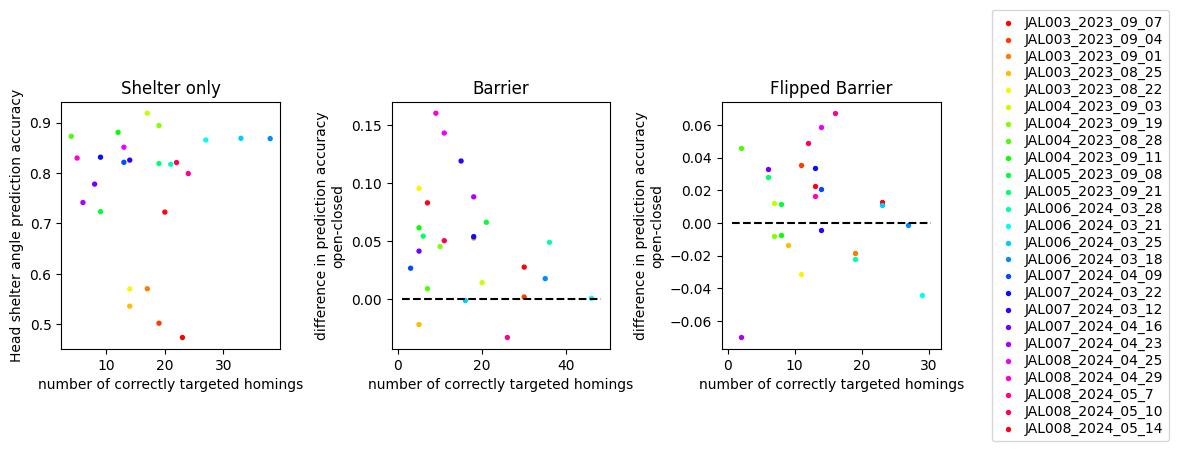

In [35]:
fig, axs = plt.subplots(1,3, figsize = (4*len(conditions),4))
colorz = plt.cm.hsv(np.linspace(0, 1, len(se['shelter_only'])))
# shelter only
axs[0].scatter(head['shelter_only'][:,1],pa['hsa'][:,0],s=8,c=colorz)
axs[0].set_xlabel('number of correctly targeted homings')
axs[0].set_ylabel('Head shelter angle prediction accuracy')
axs[0].set_title('Shelter only')

# barrier_pre_flip
axs[1].scatter(head['barrier_pre_flip'][:,0],pa['h_preflipbar_a'][:,1]-pa['h_postflipbar_a'][:,1],s=8,c=colorz)
axs[1].plot(axs[1].get_xlim(),[0,0],'--k')
axs[1].set_xlabel('number of correctly targeted homings')
axs[1].set_ylabel('difference in prediction accuracy\nopen-closed')
axs[1].set_title('Barrier')

# barrier_post_flip
line_object = []
for s,p,cz in zip(head['barrier_post_flip'][:,2],pa['h_postflipbar_a'][:,2]-pa['h_preflipbar_a'][:,2],colorz):
    line = axs[2].scatter(s,p,s=8,color=cz)
    line_object.append(line)
axs[2].plot(axs[2].get_xlim(),[0,0],'--k')
axs[2].set_xlabel('number of correctly targeted homings')
axs[2].set_ylabel('difference in prediction accuracy\nopen-closed')
axs[2].set_title('Flipped Barrier')

axs[2].legend(line_object, all_names,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)

plt.tight_layout()
plt.savefig(save_path+'/'+str('homings_number_correct_pa_diff_allsesh_'+settings+'.png'))

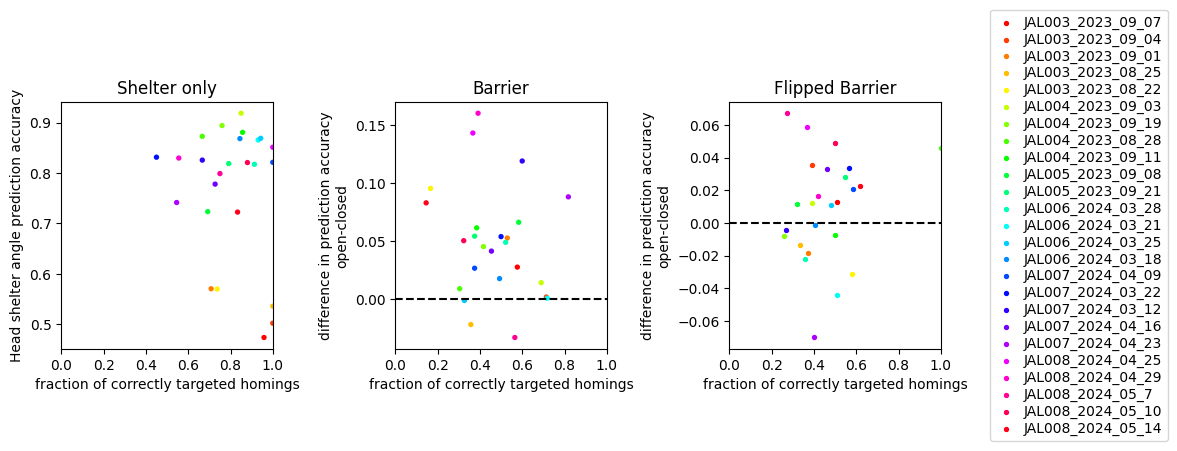

In [27]:
fig, axs = plt.subplots(1,3, figsize = (4*len(conditions),4))
colorz = plt.cm.hsv(np.linspace(0, 1, len(se['shelter_only'])))
# shelter only
axs[0].scatter(head['shelter_only'][:,1]/np.sum(head['shelter_only'], axis = 1),pa['hsa'][:,0],s=8,c=colorz)
axs[0].set_xlabel('fraction of correctly targeted homings')
axs[0].set_ylabel('Head shelter angle prediction accuracy')
axs[0].set_title('Shelter only')
axs[0].set_xlim([0,1])

# barrier_pre_flip
axs[1].scatter(head['barrier_pre_flip'][:,0]/np.sum(head['barrier_pre_flip'], axis = 1),pa['h_preflipbar_a'][:,1]-pa['h_postflipbar_a'][:,1],s=8,c=colorz)
axs[1].set_xlabel('fraction of correctly targeted homings')
axs[1].set_ylabel('difference in prediction accuracy\nopen-closed')
axs[1].set_title('Barrier')
axs[1].set_xlim([0,1])
axs[1].plot(axs[1].get_xlim(),[0,0],'--k')

# barrier_post_flip
line_object = []
for s,p,cz in zip(head['barrier_post_flip'][:,2]/np.sum(head['barrier_post_flip'], axis = 1),pa['h_postflipbar_a'][:,2]-pa['h_preflipbar_a'][:,2],colorz):
    line = axs[2].scatter(s,p,s=8,color=cz)
    line_object.append(line)
axs[2].set_xlabel('fraction of correctly targeted homings')
axs[2].set_ylabel('difference in prediction accuracy\nopen-closed')
axs[2].set_title('Flipped Barrier')
axs[2].set_xlim([0,1])
axs[2].plot(axs[2].get_xlim(),[0,0],'--k')

axs[2].legend(line_object, all_names,loc='center left', bbox_to_anchor=(1.2, 0.5),
                columnspacing=1.0, labelspacing=0.2,
                handletextpad=0.5, handlelength=1.5)

plt.tight_layout()
plt.savefig(save_path+'/'+str('homings_fraction_correct_pa_diff_allsesh_'+settings+'.png'))